<a href="https://colab.research.google.com/github/JosueSandovalZT/ManualPracticas-1/blob/main/U1_Actividad_4_Pr%C3%A1ctica_Reporte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importar librerías necesarias**

Esta celda importa las librerías `numpy` para operaciones numéricas, `pandas` para manipulación de datos y `matplotlib.pyplot` para visualización.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Importar módulos de Scikit-learn**

Aquí se importan los módulos necesarios de Scikit-learn para:
- Cargar el dataset de California Housing (`fetch_california_housing`).
- Dividir el conjunto de datos en entrenamiento y prueba (`train_test_split`).
- Implementar el modelo de regresión lineal (`LinearRegression`).
- Evaluar el modelo con métricas como el error absoluto medio (`mean_absolute_error`), el error cuadrático medio (`mean_squared_error`) y el coeficiente de determinación R² (`r2_score`).

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)

### **Cargar el dataset de California Housing**

Esta celda carga el dataset de viviendas de California utilizando `fetch_california_housing` y lo guarda en un DataFrame de pandas. Luego, imprime la descripción del dataset, que incluye información sobre las características y la variable objetivo.

In [ ]:
data = fetch_california_housing(as_frame=True)

print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### **Preparación de las variables explicativas (X) y objetivo (y)**

Se separan los datos en variables explicativas (`X`) y la variable objetivo (`y`), que es el valor medio de la vivienda (`MedHouseVal`). Posteriormente, se muestran las primeras 5 filas de cada uno para una inspección inicial.

In [ ]:
X = data.data
y = data.target

print("Primeros registros de X:")
print(X.head())

print("\nPrimeros registros de y:")
print(y.head())

Primeros registros de X:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Primeros registros de y:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


### **Verificación de las dimensiones del dataset**

Esta celda imprime las dimensiones (número de filas y columnas) de las variables `X` y `y` para confirmar la cantidad de muestras y características en el dataset.

In [ ]:
print("Dimensiones de X:", X.shape)
print("Número de valores de y:", y.shape)

Dimensiones de X: (20640, 8)
Número de valores de y: (20640,)


### **Exploración de las características (variables explicativas)**

Se muestran los nombres de las columnas de `X` y se imprimen las estadísticas descriptivas (media, desviación estándar, mínimos, máximos, cuartiles) de cada característica, lo que ayuda a entender su distribución y rango de valores.

In [ ]:
print("Variables disponibles:")
print(X.columns)

print("\nEstadísticas descriptivas:")
print(X.describe())

Variables disponibles:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Estadísticas descriptivas:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
me

### **Exploración de la variable objetivo (valor de la vivienda)**

Esta celda muestra las estadísticas descriptivas de la variable objetivo (`y`) y genera un histograma para visualizar la distribución de los valores medios de las viviendas. Esto permite identificar la forma de la distribución y posibles valores atípicos.

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


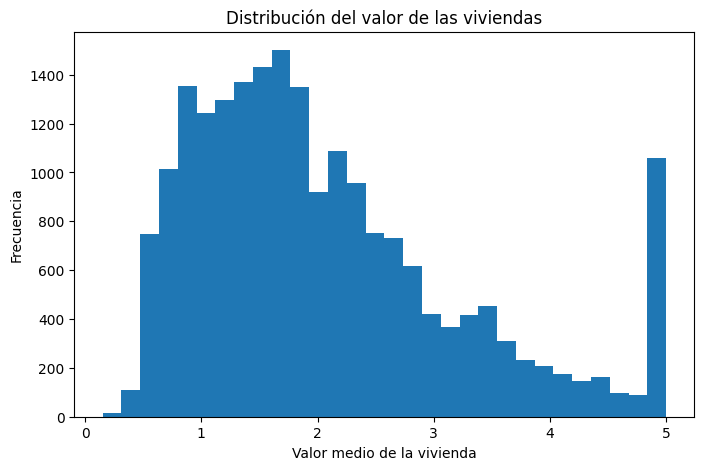

In [ ]:
print(y.describe())

plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)

plt.xlabel("Valor medio de la vivienda")
plt.ylabel("Frecuencia")
plt.title("Distribución del valor de las viviendas")

plt.show()

### **Visualización de la relación entre el ingreso medio y el valor de la vivienda**

Se crea un gráfico de dispersión para visualizar la relación entre el ingreso medio (`MedInc`) y el valor medio de la vivienda (`MedHouseVal`). La transparencia (`alpha`) ayuda a identificar la densidad de los puntos.

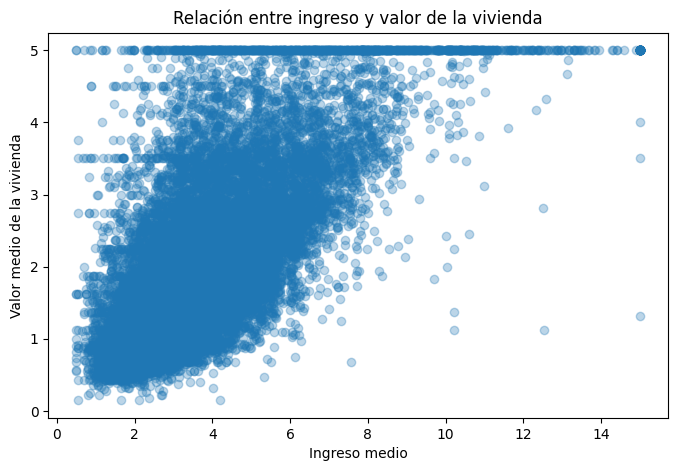

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["MedInc"],
    y,
    alpha=0.3
)

plt.xlabel("Ingreso medio")
plt.ylabel("Valor medio de la vivienda")
plt.title("Relación entre ingreso y valor de la vivienda")

plt.show()

### **Selección de la característica para el modelo simple**

Para el modelo de regresión lineal simple, se selecciona únicamente la característica `MedInc` (ingreso medio) de `X` y se guarda en `X_simple`. Se muestran las primeras filas de `X_simple`.

In [ ]:
X_simple = X[["MedInc"]]

print(X_simple.head())

   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462


### **División del dataset en conjuntos de entrenamiento y prueba**

El dataset (`X_simple`, `y`) se divide en conjuntos de entrenamiento y prueba utilizando `train_test_split`. El 20% de los datos se reserva para prueba (`test_size=0.2`), y `random_state=42` asegura la reproducibilidad de la división. Se imprimen las dimensiones de los conjuntos resultantes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (16512, 1)
Datos de prueba: (4128, 1)


### **Entrenamiento del modelo de regresión lineal simple**

Se inicializa un modelo de regresión lineal (`LinearRegression`) y se entrena utilizando los datos de entrenamiento (`X_train`, `y_train`).

In [ ]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

### **Coeficientes del modelo de regresión lineal simple**

Se imprimen el intercepto y el coeficiente del modelo entrenado, y se construye la ecuación de la línea de regresión con un formato legible.

In [ ]:
print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_[0])

print(
    f"Ecuación: MedHouseVal = {modelo.intercept_:.4f} "
    f"+ {modelo.coef_[0]:.4f}(MedInc)"
)

Intercepto: 0.4445972916907879
Coeficiente: 0.4193384939381271
Ecuación: MedHouseVal = 0.4446 + 0.4193(MedInc)


### **Realización de predicciones con el modelo simple**

Se utilizan los datos de prueba (`X_test`) para generar predicciones (`y_pred`) con el modelo de regresión lineal simple. Se muestran los primeros 10 valores reales y predichos para comparación.

In [ ]:
y_pred = modelo.predict(X_test)

print("Valores reales:")
print(y_test.iloc[:10].values)

print("\nPredicciones:")
print(y_pred[:10])

Valores reales:
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]

Predicciones:
[1.14958917 1.50606882 1.90393718 2.85059383 2.00663318 2.42165249
 2.57647226 1.99229181 2.45893168 3.84677436]


### **Evaluación del modelo de regresión lineal simple**

Esta celda calcula y muestra varias métricas de evaluación para el modelo de regresión lineal simple:
- **MAE** (Error Absoluto Medio): Promedio de los errores absolutos.
- **MSE** (Error Cuadrático Medio): Promedio de los cuadrados de los errores.
- **RMSE** (Raíz del Error Cuadrático Medio): Raíz cuadrada del MSE, en las mismas unidades que la variable objetivo.
- **R²** (Coeficiente de Determinación): Proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.629908653009376
MSE : 0.7091157771765549
RMSE: 0.8420901241414455
R²  : 0.45885918903846656


### **Visualización del modelo de regresión lineal simple**

Se crea un gráfico de dispersión que muestra los datos reales del conjunto de prueba y la línea de regresión lineal ajustada. Esto permite visualizar qué tan bien el modelo se ajusta a los datos.

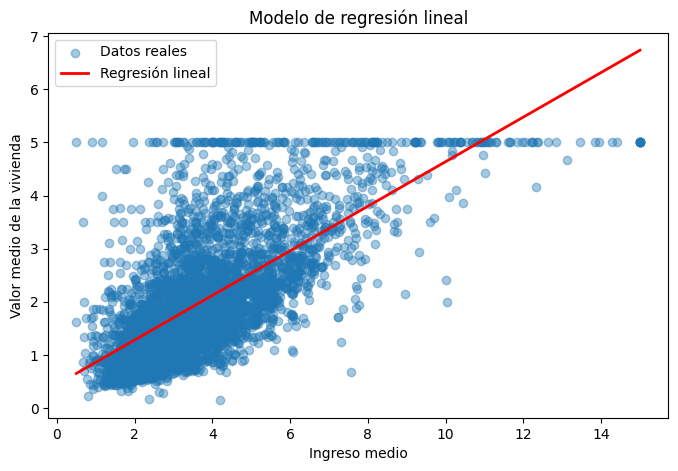

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["MedInc"],
    y_test,
    alpha=0.4,
    label="Datos reales"
)

orden = np.argsort(X_test["MedInc"].values)

plt.plot(
    X_test["MedInc"].values[orden],
    y_pred[orden],
    linewidth=2,
    color="red",
    label="Regresión lineal"
)

plt.xlabel("Ingreso medio")
plt.ylabel("Valor medio de la vivienda")
plt.title("Modelo de regresión lineal")

plt.legend()
plt.show()

### **Análisis de errores del modelo simple**

Se crea un DataFrame `comparacion` para almacenar los valores reales, las predicciones, el error (real - predicción) y el error absoluto. Se muestran las primeras 10 filas de esta comparación.

In [ ]:
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Prediccion": y_pred
})

comparacion["Error"] = (
    comparacion["Real"] - comparacion["Prediccion"]
)

comparacion["Error_Absoluto"] = (
    comparacion["Error"].abs()
)

print(comparacion.head(10))

      Real  Prediccion     Error  Error_Absoluto
0  0.47700    1.149589 -0.672589        0.672589
1  0.45800    1.506069 -1.048069        1.048069
2  5.00001    1.903937  3.096073        3.096073
3  2.18600    2.850594 -0.664594        0.664594
4  2.78000    2.006633  0.773367        0.773367
5  1.58700    2.421652 -0.834652        0.834652
6  1.98200    2.576472 -0.594472        0.594472
7  1.57500    1.992292 -0.417292        0.417292
8  3.40000    2.458932  0.941068        0.941068
9  4.46600    3.846774  0.619226        0.619226


### **Identificación de los mayores errores del modelo simple**

Se ordena el DataFrame `comparacion` por el `Error_Absoluto` en orden descendente para identificar las 10 predicciones con los mayores errores del modelo simple. Esto puede ayudar a entender dónde el modelo tiene más dificultades.

In [ ]:
mayores_errores = comparacion.sort_values(
    "Error_Absoluto",
    ascending=False
)

print(mayores_errores.head(10))

         Real  Prediccion     Error  Error_Absoluto
1649  5.00001    0.654225  4.345785        4.345785
1138  5.00001    0.822002  4.178008        4.178008
1865  5.00001    0.935056  4.064954        4.064954
1140  5.00001    1.268975  3.731035        3.731035
3761  5.00001    1.437339  3.562671        3.562671
2574  5.00001    1.481286  3.518724        3.518724
1655  5.00001    1.517601  3.482409        3.482409
3054  5.00001    1.529636  3.470374        3.470374
3231  4.50000    1.079140  3.420860        3.420860
429   5.00001    1.588343  3.411667        3.411667


### **Evaluación de la estabilidad del modelo simple con diferentes `random_state`**

Esta celda itera a través de diferentes valores de `random_state` para la división del conjunto de datos. Para cada `random_state`, se entrena un nuevo modelo simple y se calculan las métricas MAE, RMSE y R². Los resultados se almacenan en un DataFrame para evaluar la estabilidad del modelo ante diferentes particiones de los datos.

In [ ]:
resultados = []

for estado in [10, 20, 42, 100]:

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_simple,
        y,
        test_size=0.2,
        random_state=estado
    )

    modelo_exp = LinearRegression()
    modelo_exp.fit(X_train_exp, y_train_exp)

    y_pred_exp = modelo_exp.predict(X_test_exp)

    mae_exp = mean_absolute_error(
        y_test_exp,
        y_pred_exp
    )

    rmse_exp = np.sqrt(
        mean_squared_error(
            y_test_exp,
            y_pred_exp
        )
    )

    r2_exp = r2_score(
        y_test_exp,
        y_pred_exp
    )

    resultados.append([
        estado,
        mae_exp,
        rmse_exp,
        r2_exp
    ])

tabla_resultados = pd.DataFrame(
    resultados,
    columns=["random_state", "MAE", "RMSE", "R²"]
)

print(tabla_resultados)

   random_state       MAE      RMSE        R²
0            10  0.629400  0.844816  0.476960
1            20  0.629890  0.843515  0.489929
2            42  0.629909  0.842090  0.458859
3           100  0.621515  0.826852  0.492588


### **Entrenamiento y evaluación del modelo de regresión lineal múltiple**

Se prepara un modelo de regresión lineal múltiple utilizando todas las características disponibles en `X`. Los datos se dividen en entrenamiento y prueba, el modelo se entrena y se realizan predicciones. Finalmente, se calculan y se imprimen las métricas de evaluación (MAE, MSE, RMSE, R²) para este modelo más complejo.

In [ ]:
X_multiple = X

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple,
    y,
    test_size=0.2,
    random_state=42
)

modelo_multiple = LinearRegression()

modelo_multiple.fit(
    X_train_m,
    y_train_m
)

y_pred_multiple = modelo_multiple.predict(
    X_test_m
)

mae_multiple = mean_absolute_error(
    y_test_m,
    y_pred_multiple
)

mse_multiple = mean_squared_error(
    y_test_m,
    y_pred_multiple
)

rmse_multiple = np.sqrt(mse_multiple)

r2_multiple = r2_score(
    y_test_m,
    y_pred_multiple
)

print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("RMSE:", rmse_multiple)
print("R²:", r2_multiple)

MAE: 0.5332001304956553
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R²: 0.5757877060324508


### **Comparación de los modelos simple y múltiple**

Se crea un DataFrame `comparacion_modelos` para resumir y comparar las métricas de evaluación (MAE, RMSE, R²) de ambos modelos: el de regresión simple (usando solo `MedInc`) y el de regresión múltiple (usando todas las características). Esto permite identificar qué modelo ofrece un mejor rendimiento.

In [ ]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión simple",
        "Regresión múltiple"
    ],
    "Variables": [
        "MedInc",
        "Todas"
    ],
    "MAE": [
        mae,
        mae_multiple
    ],
    "RMSE": [
        rmse,
        rmse_multiple
    ],
    "R²": [
        r2,
        r2_multiple
    ]
})

print(comparacion_modelos)

               Modelo Variables       MAE      RMSE        R²
0    Regresión simple    MedInc  0.629909  0.842090  0.458859
1  Regresión múltiple     Todas  0.533200  0.745581  0.575788


### **Análisis de coeficientes del modelo de regresión múltiple**

Esta celda crea un DataFrame que muestra el coeficiente de cada característica en el modelo de regresión múltiple. También calcula la magnitud absoluta de los coeficientes y los ordena de mayor a menor para identificar qué variables tienen un mayor impacto en la predicción del valor de la vivienda.

In [ ]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_multiple.coef_
})

coeficientes["Magnitud"] = (
    coeficientes["Coeficiente"].abs()
)

coeficientes = coeficientes.sort_values(
    "Magnitud",
    ascending=False
)

print(coeficientes)

     Variable  Coeficiente  Magnitud
3   AveBedrms     0.783145  0.783145
0      MedInc     0.448675  0.448675
7   Longitude    -0.433708  0.433708
6    Latitude    -0.419792  0.419792
2    AveRooms    -0.123323  0.123323
1    HouseAge     0.009724  0.009724
5    AveOccup    -0.003526  0.003526
4  Population    -0.000002  0.000002


### **Visualización de valores reales vs. predichos del modelo múltiple**

Se genera un gráfico de dispersión que compara los valores reales con los valores predichos por el modelo de regresión múltiple en el conjunto de prueba. La línea roja representa la situación ideal donde los valores reales y predichos son iguales, ayudando a evaluar visualmente el ajuste del modelo.

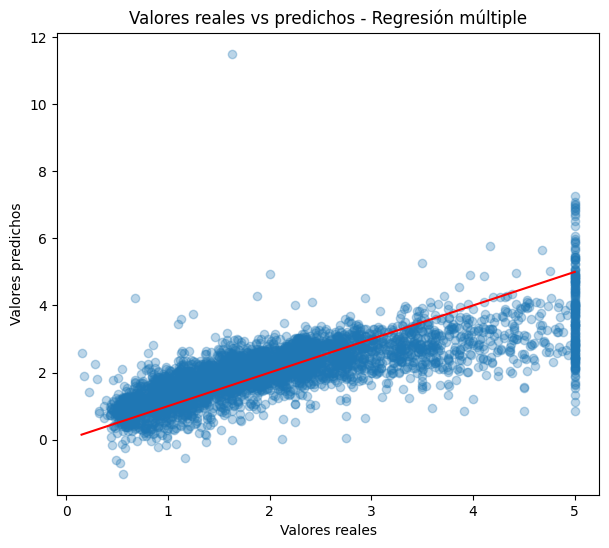

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_m,
    y_pred_multiple,
    alpha=0.3
)

plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    color="red"
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos - Regresión múltiple")

plt.show()

In [ ]:
resultados = []

for estado in [10, 20, 42, 100]:

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_simple,
        y,
        test_size=0.2,
        random_state=estado
    )

    modelo_exp = LinearRegression()
    modelo_exp.fit(X_train_exp, y_train_exp)

    y_pred_exp = modelo_exp.predict(X_test_exp)

    mae_exp = mean_absolute_error(
        y_test_exp,
        y_pred_exp
    )

    rmse_exp = np.sqrt(
        mean_squared_error(
            y_test_exp,
            y_pred_exp
        )
    )

    r2_exp = r2_score(
        y_test_exp,
        y_pred_exp
    )

    resultados.append([
        estado,
        mae_exp,
        rmse_exp,
        r2_exp
    ])

tabla_resultados = pd.DataFrame(
    resultados,
    columns=["random_state", "MAE", "RMSE", "R²"]
)

print(tabla_resultados)

   random_state       MAE      RMSE        R²
0            10  0.629400  0.844816  0.476960
1            20  0.629890  0.843515  0.489929
2            42  0.629909  0.842090  0.458859
3           100  0.621515  0.826852  0.492588


**Preguntas del reto**
1. ¿El modelo múltiple mejoró el desempeño respecto al modelo simple?

Sí, el modelo múltiple tuvo un mejor desempeño, ya que utiliza todas las variables disponibles y no solamente MedInc. Al tener más información sobre las viviendas y su ubicación, el modelo puede hacer mejores predicciones. Esto se puede comprobar comparando los valores de MAE, RMSE y R² de los dos modelos.

2. ¿Cuál de las métricas presenta la diferencia más significativa?

La diferencia se puede notar principalmente en R², ya que esta métrica muestra qué tanto logra explicar el modelo los cambios en el valor de las viviendas. También se observa una mejora en MAE y RMSE, ya que al usar más variables los errores de predicción disminuyen.

3. ¿Qué variables presentan los coeficientes de mayor magnitud?

Al revisar los coeficientes del modelo múltiple, se observa que algunas variables tienen un peso mayor que otras en las predicciones. Para saber cuáles son exactamente, se pueden ordenar los coeficientes por su valor absoluto. Hay que tomar en cuenta que las variables están medidas en diferentes escalas, así que un coeficiente grande no significa automáticamente que esa variable sea la más importante.

En esta pregunta mete los nombres que te salieron en la Celda 20. Si me mandas la captura, te la dejo respondida con tus resultados exactos.

4. ¿Un mayor número de variables garantiza siempre un mejor modelo?

No. Tener más variables no significa que el modelo automáticamente vaya a ser mejor. Algunas variables pueden aportar muy poca información o incluso hacer más complicado el modelo. Lo importante es utilizar variables que realmente tengan relación con lo que se quiere predecir.

5. ¿Qué podría hacerse para mejorar todavía más el modelo?

Se podrían analizar mejor los datos, revisar valores atípicos y probar diferentes combinaciones de variables. También sería buena idea comparar la regresión lineal con otros modelos que puedan trabajar mejor con relaciones que no sean completamente lineales.

**Comprensión**
1. ¿Qué tipo de problema de aprendizaje automático se resolvió en esta práctica y por qué?

Se resolvió un problema de aprendizaje supervisado de tipo regresión. Es supervisado porque el modelo se entrena con datos donde ya conocemos el resultado esperado y es regresión porque queremos predecir un valor numérico, que en este caso es el valor medio de las viviendas.

2. ¿Cuál es la diferencia entre una variable predictora y una variable objetivo?

La variable predictora es la información que se le proporciona al modelo para realizar una predicción. Por ejemplo, MedInc se utiliza para ayudar a predecir el precio. La variable objetivo es el resultado que queremos predecir, que en esta práctica es MedHouseVal.

3. ¿Qué representa el coeficiente asociado con MedInc en el modelo de regresión lineal?

El coeficiente de MedInc indica cómo cambia la predicción del valor de una vivienda cuando aumenta el ingreso medio. Como el coeficiente obtenido es positivo, significa que el modelo encontró que generalmente un mayor ingreso medio está relacionado con un mayor valor de vivienda.

4. ¿Por qué es necesario separar los datos en entrenamiento y prueba?

Porque necesitamos una parte de los datos para que el modelo aprenda y otra parte diferente para comprobar qué tan bien funciona. Si utilizáramos los mismos datos para entrenar y evaluar, no sabríamos realmente cómo se comportaría el modelo con información que nunca había visto.

5. ¿Qué información proporcionan MAE, RMSE y R², y por qué es conveniente utilizar más de una métrica para evaluar un modelo?

El MAE muestra el error promedio entre las predicciones y los valores reales. El RMSE también mide el error, pero le da más importancia a los errores grandes. Por otro lado, R² indica qué tanto de la variación de los datos logra explicar el modelo. Es mejor utilizar varias métricas porque cada una muestra algo diferente y así podemos evaluar mejor si el modelo realmente está funcionando bien.

**CONCLUSIONES**

Diego - En esta práctica aprendí cómo se pueden utilizar la regresión lineal simple y múltiple para predecir el valor de viviendas. Para construir los modelos primero exploré los datos, realicé la división entre entrenamiento y prueba, entrené los modelos y finalmente evalué los resultados mediante MAE, RMSE y R². Pude observar que la regresión múltiple considera más información que la regresión simple, lo que permite obtener mejores predicciones. Considero que el RMSE es una métrica importante porque permite identificar con mayor peso los errores grandes. Como limitación, la regresión lineal no puede representar correctamente relaciones más complejas entre los datos. Para mejorar las predicciones probaría otros modelos de aprendizaje automático y realizaría un análisis más detallado de las variables.


Zabdiel - En esta práctica aprendí cómo se pueden utilizar la regresión lineal simple y múltiple para predecir el valor de viviendas. Para construir los modelos primero exploré los datos, realicé la división entre entrenamiento y prueba, entrené los modelos y finalmente evalué los resultados mediante MAE, RMSE y R². Pude observar que la regresión múltiple considera más información que la regresión simple, lo que permite obtener mejores predicciones. Considero que el RMSE es una métrica importante porque permite identificar con mayor peso los errores grandes. Como limitación, la regresión lineal no puede representar correctamente relaciones más complejas entre los datos. Para mejorar las predicciones probaría otros modelos de aprendizaje automático y realizaría un análisis más detallado de las variables.
